In [64]:
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import pickle
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt

In [65]:
df = pd.read_csv('cleaned_deceptive-opinion.csv')

In [66]:
df.isnull().sum()

deceptive    0
hotel        0
polarity     0
source       0
text         0
dtype: int64

In [67]:
tf.keras.utils.set_random_seed(42)

In [68]:
df['target'] = df['deceptive'].map({'deceptive': 1, 'truthful': 0})
X = df['text']
y = df['target']

In [69]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [70]:
vocab_size = 5000
max_length = 200
tokenizer = Tokenizer(num_words=vocab_size, oov_token='<OOV>')
tokenizer.fit_on_texts(x_train)

In [71]:
x_train_padded = pad_sequences(tokenizer.texts_to_sequences(x_train), maxlen=max_length, padding='post')
x_test_padded = pad_sequences(tokenizer.texts_to_sequences(x_test), maxlen=max_length, padding='post')

In [72]:
model = tf.keras.Sequential([
    tf.keras.layers.Embedding(vocab_size, 16, input_length=max_length),
    tf.keras.layers.GlobalAveragePooling1D(),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

c:\Users\omar\Desktop\Gam3a\NLP\Project\nlp_env\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [73]:
history = model.fit(x_train_padded, y_train, epochs=10, validation_data=(x_test_padded, y_test))

Epoch 1/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.4930 - loss: 0.6938 - val_accuracy: 0.4812 - val_loss: 0.6932
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5523 - loss: 0.6917 - val_accuracy: 0.4875 - val_loss: 0.6947
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5422 - loss: 0.6897 - val_accuracy: 0.5063 - val_loss: 0.6884
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5625 - loss: 0.6857 - val_accuracy: 0.5063 - val_loss: 0.6918
Epoch 5/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5820 - loss: 0.6799 - val_accuracy: 0.5344 - val_loss: 0.6758
Epoch 6/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6453 - loss: 0.6621 - val_accuracy: 0.5781 - val_loss: 0.6557
Epoch 7/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6711 - loss: 0.6373 - val_accuracy: 0.5625 - val_loss: 0.6426
Epoch 8/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7617 - loss: 0.6068 - val_accuracy: 0.5813 - val_loss:

In [74]:
classification_report = model.predict(x_test_padded)
y_pred = (classification_report > 0.5).astype(int)
accuracy_score = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy_score}')

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Accuracy: 0.815625


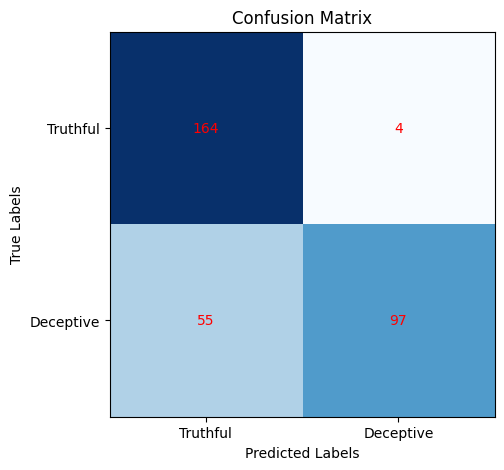

In [75]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 5))
plt.imshow(cm, cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.xticks([0, 1], ['Truthful', 'Deceptive'])
plt.yticks([0, 1], ['Truthful', 'Deceptive'])
for i in range(len(cm)):
    for j in range(len(cm[i])):
        plt.text(j, i, cm[i][j], ha='center', va='center', color='red')
plt.show()

In [76]:
model.save('nn_model.keras')
with open('nn_tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)